# 05 · Predicting Churn & 90-Day Customer Value (Supervised ML)

RFM and clustering describe the **past**. Here we **predict the future**:
1. **Churn model (classification):** *will an active customer buy again in the next 90 days?*
2. **Value model (regression):** *how much will they spend in the next 90 days?* (a short-horizon Customer Lifetime Value, or CLV)

> 📘 **Defining churn.** In retail there's no "account closed" event, so we *define* churn: an active customer (bought in the last 365 days) who makes **no purchase in the next 90 days**. Stating this definition clearly is one of the "key assumptions" the HSBC JD asks you to communicate.

> 📘 **The #1 trap: data leakage.** If features accidentally use information from the future, the model looks brilliant in testing and fails in real life. We prevent this with **point-in-time snapshots**:
> - pick a *cutoff date*;
> - build features **only from data before** the cutoff;
> - build the label **only from the 90 days after** it.
>
> And we validate **out-of-time**: train on earlier snapshots, test on the latest one, just as the model would be used in production. (Banks do exactly this when validating credit-risk models.)

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (roc_auc_score, average_precision_score, roc_curve, classification_report,
                             mean_absolute_error)
from sklearn.inspection import permutation_importance

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESSED = ROOT / "data" / "processed"
FIGS = ROOT / "reports" / "figures"
sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", "{:,.3f}".format)

sales = pd.read_parquet(PROCESSED / "sales_clean.parquet")
returns = pd.read_parquet(PROCESSED / "returns_clean.parquet")
tx = sales[sales["HasCustomer"]].copy()
rt = returns[returns["CustomerID"].notna()].copy()
HORIZON = pd.Timedelta(days=90)

## 1. Feature engineering (point-in-time)
For each cutoff date we compute behavioural features per customer using **only past data**. Beyond R/F/M we add signals that often predict churn: recent activity trend, purchase rhythm, product variety, return behaviour.

In [2]:
def make_features(cutoff):
    cutoff = pd.Timestamp(cutoff)
    hist = tx[tx["InvoiceDate"] < cutoff]
    # population = "active" customers: bought at least once in the 365 days before cutoff
    active = hist.loc[hist["InvoiceDate"] >= cutoff - pd.Timedelta(days=365), "CustomerID"].unique()
    h = hist[hist["CustomerID"].isin(active)]
    g = h.groupby("CustomerID")

    f = pd.DataFrame({
        "recency_days": (cutoff - g["InvoiceDate"].max()).dt.days,
        "tenure_days": (cutoff - g["InvoiceDate"].min()).dt.days,
        "frequency": g["Invoice"].nunique(),
        "monetary": g["Revenue"].sum(),
        "n_products": g["StockCode"].nunique(),
        "months_active": g["YearMonth"].nunique(),
    })
    for days in (90, 365):
        w = h[h["InvoiceDate"] >= cutoff - pd.Timedelta(days=days)].groupby("CustomerID")
        f[f"orders_{days}d"] = w["Invoice"].nunique()
        f[f"revenue_{days}d"] = w["Revenue"].sum()
    f = f.fillna(0)
    f["aov"] = f["monetary"] / f["frequency"]
    span = (g["InvoiceDate"].max() - g["InvoiceDate"].min()).dt.days
    f["avg_gap_days"] = np.where(f["frequency"] > 1, span / (f["frequency"] - 1), f["tenure_days"])
    # "overdue" ratio: how late is the customer vs their own usual rhythm? (>1 = later than usual)
    f["overdue_ratio"] = f["recency_days"] / f["avg_gap_days"].clip(lower=1)
    ret = rt[rt["InvoiceDate"] < cutoff].groupby("CustomerID")["ReturnValue"].sum()
    f["return_rate"] = (ret.reindex(f.index).fillna(0) / f["monetary"]).clip(0, 1)
    f["is_uk"] = (g["Country"].agg(lambda c: c.mode().iat[0]) == "United Kingdom").astype(int)
    return f

def make_labels(cutoff, index):
    cutoff = pd.Timestamp(cutoff)
    fut = tx[(tx["InvoiceDate"] >= cutoff) & (tx["InvoiceDate"] < cutoff + HORIZON)]
    rev = fut.groupby("CustomerID")["Revenue"].sum().reindex(index).fillna(0)
    return pd.DataFrame({"churn": (rev == 0).astype(int), "future_revenue": rev}, index=index)

## 2. Build train and test snapshots
- **Train:** 4 quarterly cutoffs (Sep-2010 → Jun-2011). Stacking several snapshots gives more data and covers every season.
- **Test:** cutoff 11-Sep-2011, labels = 11-Sep → 9-Dec-2011. The model has **never seen** this period.
- Label windows of the training snapshots end *before* the test cutoff, so there's no overlap.

In [3]:
TRAIN_CUTOFFS = ["2010-09-12", "2010-12-12", "2011-03-13", "2011-06-12"]
TEST_CUTOFF = "2011-09-11"

def snapshot(cutoff):
    X = make_features(cutoff)
    return X, make_labels(cutoff, X.index).assign(cutoff=cutoff)

parts = [snapshot(c) for c in TRAIN_CUTOFFS]
X_train = pd.concat([p[0] for p in parts]); y_train = pd.concat([p[1] for p in parts])
X_test, y_test = snapshot(TEST_CUTOFF)

summary = pd.concat([y_train.assign(split="train"), y_test.assign(split="test")]) \
    .groupby(["split", "cutoff"]).agg(customers=("churn", "size"), churn_rate=("churn", "mean"))
summary

customers  churn_rate
split cutoff                           
test  2011-09-11       4301       0.492
train 2010-09-12       3355       0.421
      2010-12-12       4214       0.689
      2011-03-13       4283       0.628
      2011-06-12       4318       0.639

Roughly **half** of active customers don't buy in any given 90-day window. The test period (Q4 peak) has *lower* churn than average: a real-world **distribution shift** the model must cope with.

## 3. Churn model: baseline vs gradient boosting
Always start with a **simple, interpretable baseline**:
- **Logistic Regression:** linear, explainable, the "bank-standard" model (credit scorecards are logistic regressions).
- **Histogram Gradient Boosting:** an ensemble of decision trees, captures non-linear patterns. Usually stronger on tabular data.

📘 **Metrics:**
- **ROC-AUC:** probability the model ranks a random churner above a random non-churner (0.5 = coin flip, 1 = perfect).
- **PR-AUC (average precision):** focuses on the positive class.
- **Lift:** "if we only contact the 10% riskiest customers, how much more likely are they to churn than an average customer?" (lift = churn rate in that group ÷ overall churn rate). This is the metric business stakeholders actually care about.

In [4]:
FEATURES = list(X_train.columns)
log_scale = make_pipeline(FunctionTransformer(np.log1p), StandardScaler())

models = {
    "Logistic Regression": make_pipeline(log_scale, LogisticRegression(max_iter=2000)),
    "Gradient Boosting": HistGradientBoostingClassifier(max_iter=300, learning_rate=0.05, max_leaf_nodes=15,
                                                        min_samples_leaf=40, l2_regularization=1.0, random_state=42),
}
scores = {}
for name, model in models.items():
    model.fit(X_train[FEATURES], y_train["churn"])
    p = model.predict_proba(X_test[FEATURES])[:, 1]
    scores[name] = p
    top10 = pd.Series(p, index=X_test.index).rank(ascending=False, pct=True) <= 0.1
    top_rate = y_test.loc[top10, "churn"].mean()
    print(f"{name:20s} ROC-AUC={roc_auc_score(y_test['churn'], p):.3f}  "
          f"PR-AUC={average_precision_score(y_test['churn'], p):.3f}  "
          f"riskiest 10% churn rate={top_rate:.0%} vs {y_test['churn'].mean():.0%} overall "
          f"(lift {top_rate / y_test['churn'].mean():.1f}x)")

Logistic Regression  ROC-AUC=0.774  PR-AUC=0.728  riskiest 10% churn rate=79% vs 49% overall (lift 1.6x)
Gradient Boosting    ROC-AUC=0.768  PR-AUC=0.726  riskiest 10% churn rate=79% vs 49% overall (lift 1.6x)


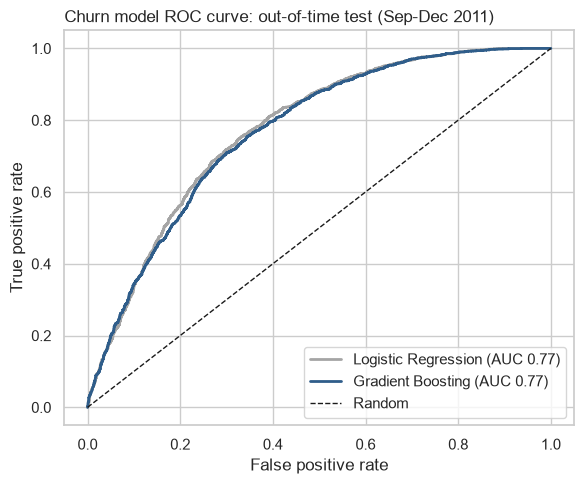

In [5]:
fig, ax = plt.subplots(figsize=(6, 5))
for (name, p), c in zip(scores.items(), ["#A5A5A5", "#2F5D8A"]):
    fpr, tpr, _ = roc_curve(y_test["churn"], p)
    ax.plot(fpr, tpr, color=c, lw=2, label=f"{name} (AUC {roc_auc_score(y_test['churn'], p):.2f})")
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random")
ax.set_xlabel("False positive rate"); ax.set_ylabel("True positive rate")
ax.set_title("Churn model ROC curve: out-of-time test (Sep-Dec 2011)", loc="left"); ax.legend()
plt.tight_layout(); plt.savefig(FIGS / "05_roc.png", dpi=150); plt.show()

### Classification report at threshold 0.5
**Precision** = of those we flag as churners, how many really churn? **Recall** = of all real churners, how many did we flag? The business chooses the trade-off: a cheap email campaign tolerates low precision; an expensive account-manager call needs high precision.

In [6]:
# Principle of parsimony: if the complex model isn't clearly better (> 0.01 AUC), keep the simple, explainable one
auc = {n: roc_auc_score(y_test["churn"], p) for n, p in scores.items()}
best_name = "Gradient Boosting" if auc["Gradient Boosting"] > auc["Logistic Regression"] + 0.01 else "Logistic Regression"
best = models[best_name]
p_test = scores[best_name]
print(f"Chosen model: {best_name}. Gradient boosting did not clearly beat the simpler, explainable baseline.\n"
      if best_name == "Logistic Regression" else f"Chosen model: {best_name}\n")
print(classification_report(y_test["churn"], (p_test >= 0.5).astype(int), target_names=["Stays", "Churns"]))

Chosen model: Logistic Regression. Gradient boosting did not clearly beat the simpler, explainable baseline.

              precision    recall  f1-score   support

       Stays       0.83      0.46      0.59      2184
      Churns       0.62      0.90      0.74      2117

    accuracy                           0.68      4301
   macro avg       0.73      0.68      0.66      4301
weighted avg       0.73      0.68      0.66      4301



### Calibration check: are the probabilities trustworthy?
If the model says 70% churn risk, about 70% of such customers should actually churn. We bin predictions into deciles and compare.

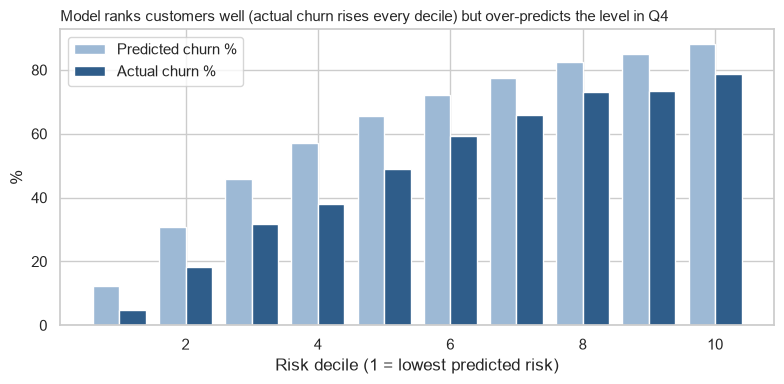

,predicted,actual,customers
decile,,,
1,0.123,0.046,431
2,0.307,0.181,430
3,0.457,0.319,430
4,0.570,0.381,430
5,0.656,0.491,430
6,0.720,0.593,430
7,0.775,0.658,430
8,0.825,0.730,430
9,0.851,0.735,430


In [7]:
cal = pd.DataFrame({"p": p_test, "y": y_test["churn"].values})
cal["decile"] = pd.qcut(cal["p"], 10, labels=False, duplicates="drop") + 1
cal_tbl = cal.groupby("decile").agg(predicted=("p", "mean"), actual=("y", "mean"), customers=("y", "size"))
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(cal_tbl.index - 0.2, cal_tbl["predicted"] * 100, 0.4, label="Predicted churn %", color="#9DB9D5")
ax.bar(cal_tbl.index + 0.2, cal_tbl["actual"] * 100, 0.4, label="Actual churn %", color="#2F5D8A")
ax.set_xlabel("Risk decile (1 = lowest predicted risk)"); ax.set_ylabel("%"); ax.legend()
ax.set_title("Model ranks customers well (actual churn rises every decile) but over-predicts the level in Q4",
             loc="left", fontsize=11)
plt.tight_layout(); plt.savefig(FIGS / "05_calibration.png", dpi=150); plt.show()
cal_tbl

**Reading this chart honestly:** actual churn rises steadily from decile 1 (~5%) to decile 10 (~80%), so the **ranking is excellent**. But predicted levels sit above actual ones. Why? The training snapshots averaged ~60% churn, while the test quarter (Sep-Dec, Christmas peak) had only ~49%. That's **seasonal distribution shift**. In production you'd fix it by recalibrating per season or adding seasonal features. For *prioritising* who to contact, the ranking is what matters.

## 4. What drives churn? (Explainability)
**Permutation importance:** shuffle one feature at a time and measure how much ROC-AUC drops. A big drop means the model relies on that feature. This works for any model, which matters in banking, where regulators expect models to be explainable.

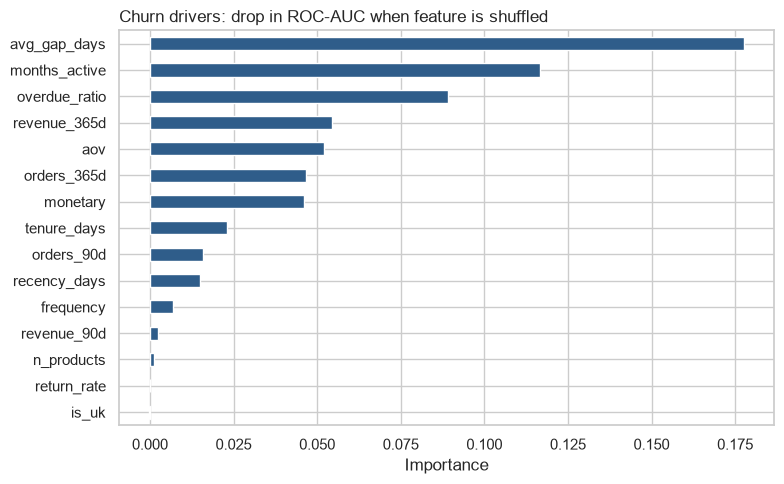

In [8]:
pi = permutation_importance(best, X_test[FEATURES], y_test["churn"], scoring="roc_auc", n_repeats=5, random_state=42)
imp = pd.Series(pi.importances_mean, index=FEATURES).sort_values()
fig, ax = plt.subplots(figsize=(8, 5))
imp.plot.barh(ax=ax, color="#2F5D8A")
ax.set_title("Churn drivers: drop in ROC-AUC when feature is shuffled", loc="left"); ax.set_xlabel("Importance")
plt.tight_layout(); plt.savefig(FIGS / "05_feature_importance.png", dpi=150); plt.show()

**Interpretation:** the strongest signals are *behavioural rhythm*: how often a customer normally buys (`avg_gap_days`), how consistently (`months_active`), and whether they're late vs their own habit (`overdue_ratio`). A customer who orders monthly and hasn't ordered in 3 months is a much bigger warning sign than a once-a-year buyer with the same recency.

⚠️ Permutation importance splits credit between correlated features: `recency_days` looks weak only because `overdue_ratio` already contains it.

## 5. 90-day value model (regression): does ML beat a simple rule?
Predict **how much** each customer will spend in the next 90 days (zero for churners).

A model is only worth deploying if it beats the obvious rules, so we compare against two **baselines**:
- *Naive-90:* next 90 days = last 90 days
- *Avg quarter:* next 90 days = last 365 days ÷ 4

📘 We use **Poisson loss**, which suits non-negative, skewed targets with many zeros (half the customers spend £0). Metrics: **MAE** (average £ error per customer) and **top-10% capture** (how much of actual revenue sits in the customers the method ranks highest).

In [9]:
reg = HistGradientBoostingRegressor(loss="poisson", max_iter=300, learning_rate=0.05, max_leaf_nodes=15,
                                    min_samples_leaf=40, random_state=42)
reg.fit(X_train[FEATURES], y_train["future_revenue"])
actual = y_test["future_revenue"].values
candidates = {
    "Baseline: last 90 days": X_test["revenue_90d"].values,
    "Baseline: avg quarter (365d / 4)": X_test["revenue_365d"].values / 4,
    "Gradient Boosting (Poisson)": np.clip(reg.predict(X_test[FEATURES]), 0, None),
}

def top_capture(pred, k=0.1):
    top = pd.Series(pred).rank(ascending=False, method="first", pct=True) <= k
    return actual[top.values].sum() / actual.sum()

val_tbl = pd.DataFrame({name: {"MAE (£)": mean_absolute_error(actual, p),
                               "Top-10% capture of actual revenue": top_capture(p),
                               "Predicted total (£)": p.sum()} for name, p in candidates.items()}).T
print(f"Actual total revenue in test window: £{actual.sum():,.0f}")
val_tbl

Actual total revenue in test window: £2,776,216


,MAE (£),Top-10% capture of actual revenue,Predicted total (£)
Baseline: last 90 days,500.398,0.543,"1,817,273.360"
Baseline: avg quarter (365d / 4),446.619,0.578,"2,001,016.867"
Gradient Boosting (Poisson),460.492,0.577,"1,744,577.626"


**Honest result:** the ML model does **not** beat the simple "average quarter" baseline. MAE and ranking are about equal. So we **deploy the baseline** for customer value: it's simpler, transparent and just as accurate.

This is a genuinely important lesson (and a great interview answer): *complexity must earn its place*. Why doesn't ML win here? Individual B2B orders are lumpy and driven by things not in the data (a customer's own sales, promotions, stock levels). Everyone under-predicts the Q4 total because the Christmas peak is a *seasonal* effect, which we model at company level in notebook 06.

## 6. Score today's customers (deployment)
Retrain on **all** labelled snapshots (train + test) and score every active customer as of 10-Dec-2011. These scores feed the Power BI dashboard.

**Revenue at risk** = churn probability × customer's average quarterly revenue over the last year (the value baseline chosen above). This combines *how likely* with *how much it matters*: a £50k customer at 60% risk matters more than a £200 customer at 90% risk.

In [10]:
X_all = pd.concat([X_train, X_test]); y_all = pd.concat([y_train, y_test])
best.fit(X_all[FEATURES], y_all["churn"])

SCORE_DATE = "2011-12-10"
X_now = make_features(SCORE_DATE)
scored = pd.DataFrame(index=X_now.index)
scored["ChurnProbability"] = best.predict_proba(X_now[FEATURES])[:, 1]
scored["QuarterlyRevenue"] = X_now["revenue_365d"] / 4
scored["RevenueAtRisk"] = scored["ChurnProbability"] * scored["QuarterlyRevenue"]
scored["RiskBand"] = pd.cut(scored["ChurnProbability"], [0, .3, .6, 1], labels=["Low", "Medium", "High"], include_lowest=True)
scored = scored.reset_index()

rfm = pd.read_parquet(PROCESSED / "rfm_clusters.parquet")
scored = scored.merge(rfm[["CustomerID", "Segment", "ClusterName"]], on="CustomerID", how="left")
print(f"Scored {len(scored):,} active customers. Total revenue at risk next quarter: £{scored['RevenueAtRisk'].sum():,.0f}")
scored.groupby("RiskBand", observed=True).agg(Customers=("CustomerID", "size"),
                                              RevenueAtRisk=("RevenueAtRisk", "sum"))

Scored 4,260 active customers. Total revenue at risk next quarter: £441,666


,Customers,RevenueAtRisk
RiskBand,,
Low,950,"121,563.742"
Medium,1233,"157,884.392"
High,2077,"162,218.028"


### Priority call list: high value × high risk
The top 10 customers by revenue at risk. This is what you'd hand to the account-management team on Monday morning.

In [11]:
scored.sort_values("RevenueAtRisk", ascending=False).head(10)[
    ["CustomerID", "Segment", "ChurnProbability", "QuarterlyRevenue", "RevenueAtRisk"]]

,CustomerID,Segment,ChurnProbability,QuarterlyRevenue,RevenueAtRisk
1983,15098,Need Attention,0.714,"9,979.125","7,124.536"
2467,15749,Hibernating,0.646,"3,705.500","2,395.528"
194,12590,Hibernating,0.633,"2,335.315","1,477.977"
9,12357,Potential Loyalists,0.720,"1,551.918","1,117.106"
556,13093,Can't Lose Them,0.624,"1,758.267","1,097.008"
3708,17509,Loyal Customers,0.694,"1,520.910","1,055.081"
325,12753,Loyal Customers,0.196,"5,357.347","1,050.225"
1267,14088,Champions,0.073,"12,622.952",918.678
54,12415,Loyal Customers,0.029,"31,141.132",908.634
4151,18139,Champions,0.429,"2,109.585",905.139


In [12]:
scored.to_parquet(PROCESSED / "customer_scores.parquet", index=False)
pd.DataFrame({"model": list(scores), "roc_auc": [roc_auc_score(y_test["churn"], p) for p in scores.values()]}) \
  .to_csv(PROCESSED / "model_metrics.csv", index=False)
print("Saved customer_scores.parquet and model_metrics.csv")

Saved customer_scores.parquet and model_metrics.csv


## ✅ Key takeaways
1. **Churn defined** as no purchase in the next 90 days among customers active in the past year.
2. **Point-in-time features + out-of-time validation** prevent leakage and mimic real deployment.
3. Churn model: ROC-AUC ≈ 0.77 out-of-time; the riskiest 10% churn at ~1.6× the average rate. Logistic regression matched gradient boosting, so we kept the **simpler, explainable** model.
4. **Top drivers:** a customer's usual purchase rhythm (avg gap between orders), consistency (months active) and how "overdue" they are vs their own rhythm. Raw recency ranks low because its information is already inside the overdue ratio (correlated features share importance).
5. For customer value, ML did **not** beat a simple average-quarter baseline, so we deployed the baseline.
6. **Revenue at risk** combines probability and value into one prioritisation metric.

**Assumptions & limitations:** the 90-day churn window is a business choice (not a fact); the test period is Q4 peak (seasonal shift); probabilities over-predict churn in peak season (recalibration needed); B2B wholesale orders are lumpy, so individual £ values are noisy and best used for *ranking*, not budgeting.